# Replication Project Tour

This notebook provides a brief tour of the cleaned data and the main analysis pipeline for our replication project. The goal is to show how firm-level news headlines, GPT-generated sentiment labels, and CRSP stock return data are combined to construct and evaluate a news-based trading strategy.

The notebook focuses on the cleaned datasets, the intermediate processing steps, and the final portfolio outputs.

## 1. Imports and setup

In [20]:
import sys
from pathlib import Path
sys.path.append(str(Path("src").resolve()))

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import compute_portfolio_performance  as cpp
import graph_trading_strategy as gts

DATA_DIR = Path("_data")
OUTPUT_DIR = Path("_output")

## 2. Project pipeline

The analysis proceeds in four main steps:

1. Load labeled RavenPack headlines and classify them as intraday or overnight.

2. Merge headlines with CRSP daily prices and TAQ minute data.

3. Compute event returns such as initial reaction and drift.

4. Construct long-short, long-only, and short-only portfolios and summarize performance.

## 3. Split headlines into intraday and overnight samples

The first important step is to divide the labeled headlines into intraday and overnight news. This matters because the return measurement differs across the two groups.

In [22]:
intraday_headlines, overnight_headlines = cpp._divide_intraday_overnight()

print("Intraday headlines shape:", intraday_headlines.shape)
print("Overnight headlines shape:", overnight_headlines.shape)

overnight_headlines.head()

Intraday headlines shape: (24807, 14)
Overnight headlines shape: (133915, 14)


,rp_story_id,ticker,headline,label,score,model,created_at,raw_response,prompt_version,timestamp_utc,timestamp_et,date,is_intraday,t15
0,99B776742AC43D2576B38F0623476EAD,AKBA,Akebia Therapeutics to Present at the Jefferie...,UNKNOWN,0.0,gpt-4o-mini,,UNKNOWN \nThe impact of the presentation on s...,v1,2024-05-23 12:00:10.247,2024-05-23 08:00:10.247000-04:00,2024-05-23,False,2024-05-23 08:15:00-04:00
1,62C842365FC08376D46BB30CDE33FF0C,LMNR,Limoneira's Joint Venture with Lewis Group of ...,YES,1.0,gpt-4o-mini,,YES \nThe approval for additional dwelling un...,v1,2024-05-07 12:30:01.334,2024-05-07 08:30:01.334000-04:00,2024-05-07,False,2024-05-07 08:45:00-04:00
2,755A5C97E1CC274D5A5BFEE3F77C6864,LFCR,"CEO Josephs Surrenders 8,975 Of Lifecore Biome...",NO,-1.0,gpt-4o-mini,,NO \nThe surrendering of shares by the CEO ma...,v1,2024-05-22 21:50:38.545,2024-05-22 17:50:38.545000-04:00,2024-05-23,False,2024-05-22 18:05:00-04:00
4,DEAF2646410407F9B8D103502C4DBEAE,SJM,CFO Marshall Surrenders 443 Of JM Smucker Co/T...,NO,-1.0,gpt-4o-mini,,NO \nThe resignation of a CFO can create unce...,v1,2023-10-02 23:55:25.809,2023-10-02 19:55:25.809000-04:00,2023-10-03,False,2023-10-02 20:10:00-04:00
5,06BB831F0CF4C65AA79D7553D76943C0,MAN,"VP Mondano Sells 2,500 Of ManpowerGroup Inc >MAN",NO,-1.0,gpt-4o-mini,,NO \nThe sale of shares by a VP may signal a ...,v1,2023-02-27 21:42:31.889,2023-02-27 16:42:31.889000-05:00,2023-02-28,False,2023-02-27 16:57:00-05:00


## 4. Cleaned overnight sample

For overnight headlines, the code merges the news data with CRSP daily price data and computes two main variables:

- `initial_reaction`: return from previous close to current open
- `drift`: return from current open to current close

In [23]:
overnight_clean = cpp._merge_overnight(overnight_headlines)

print("Cleaned overnight shape:", overnight_clean.shape)
overnight_clean.head()

Cleaned overnight shape: (129059, 6)


,ticker,headline,label,date,initial_reaction,drift
0,AKBA,Akebia Therapeutics to Present at the Jefferie...,UNKNOWN,2024-05-23,-0.009091,0.000000
1,LMNR,Limoneira's Joint Venture with Lewis Group of ...,YES,2024-05-07,0.016667,-0.010773
2,LFCR,"CEO Josephs Surrenders 8,975 Of Lifecore Biome...",NO,2024-05-23,0.012007,-0.035593
3,SJM,CFO Marshall Surrenders 443 Of JM Smucker Co/T...,NO,2023-10-03,-0.006093,-0.002568
4,MAN,"VP Mondano Sells 2,500 Of ManpowerGroup Inc >MAN",NO,2023-02-28,-0.004135,0.006880


## 5. Cleaned intraday sample

For intraday headlines, the code uses TAQ minute data together with CRSP daily prices. The midpoint price around the event time is used to measure the immediate market reaction.

In [24]:
intraday_clean = cpp._merge_intraday(intraday_headlines)

print("Cleaned intraday shape:", intraday_clean.shape)
intraday_clean.head()

Cleaned intraday shape: (19766, 7)


,ticker,headline,label,date,closeprc,initial_reaction,drift
0,BR,Broadridge Declares Quarterly Dividend of $0.7...,YES,2023-05-10,154.85001,0.009636,-0.000969
4,EHC,Encompass Health to participate in the Credit ...,UNKNOWN,2021-10-18,68.28000,-0.011831,-0.007323
5,CHGG,"Chegg Expected to Post 2Q Loss, Lower Revenue ...",NO,2023-08-07,10.03000,0.011916,0.042871
6,DLTR,Dollar Tree Shares Fall 14% After Cutting Prof...,NO,2023-05-25,136.66000,-0.133022,0.042368
11,GPI,Group 1 Automotive to Present at the Stephens ...,UNKNOWN,2021-12-01,189.46001,0.007266,0.069777


## 6. Basic data checks

Before constructing portfolios, it is useful to inspect the label distribution and summary statistics of the constructed return variables.

In [25]:
print("Overnight label counts:")
print(overnight_clean["label"].value_counts(dropna=False))

print("\nIntraday label counts:")
print(intraday_clean["label"].value_counts(dropna=False))

Overnight label counts:
label
UNKNOWN    56227
YES        52506
NO         20326
Name: count, dtype: int64

Intraday label counts:
label
YES        9475
UNKNOWN    5506
NO         4785
Name: count, dtype: int64


In [26]:
print("Overnight return summary:")
display(overnight_clean[["initial_reaction", "drift"]].describe())

print("Intraday return summary:")
display(intraday_clean[["initial_reaction", "drift"]].describe())

Overnight return summary:


,initial_reaction,drift
count,129059.000000,129059.000000
mean,0.001300,-0.000353
std,0.047232,0.045948
min,-0.197175,-0.155674
25%,-0.009434,-0.019449
50%,0.000356,0.000000
75%,0.011715,0.018149
max,0.189496,0.161503


Intraday return summary:


,initial_reaction,drift
count,19766.000000,19766.000000
mean,0.005623,0.000387
std,0.070772,0.036824
min,-0.234005,-0.131931
25%,-0.012504,-0.014206
50%,0.000828,0.000000
75%,0.015123,0.014237
max,0.360301,0.154210


## 7. Example of signal construction

The portfolio logic maps GPT labels into trading signals:

- `YES` → long signal
- `NO` → short signal
- `UNKNOWN` → excluded from trading

In [27]:
demo = overnight_clean.copy()
demo["signal"] = demo["label"].map({"YES": 1, "NO": -1, "UNKNOWN": 0})

demo[["ticker", "date", "label", "signal", "initial_reaction", "drift"]].head()

,ticker,date,label,signal,initial_reaction,drift
0,AKBA,2024-05-23,UNKNOWN,0,-0.009091,0.000000
1,LMNR,2024-05-07,YES,1,0.016667,-0.010773
2,LFCR,2024-05-23,NO,-1,0.012007,-0.035593
3,SJM,2023-10-03,NO,-1,-0.006093,-0.002568
4,MAN,2023-02-28,NO,-1,-0.004135,0.006880


## 8. Main performance table

The next step is to reproduce the main performance summary. The table reports results for long-short, long-only, and short-only portfolios across overnight and intraday samples.

In [28]:
results = cpp._compute_metrics()
performance_table = cpp.build_performance_table(results)

cpp.style_performance_table(performance_table)

## 9. Cumulative return figure

We now reproduce the main cumulative return plot for the trading strategy and compare it with a value-weighted market benchmark.

In [29]:
intraday_headlines_g, overnight_headlines_g = gts._divide_intraday_overnight()
overnight_graph_clean = gts._merge_overnight(overnight_headlines_g)

cumret_long_short = gts.long_short_strategy(overnight_graph_clean)
cumret_not_small = gts.long_short_not_small(overnight_graph_clean)
cumret_price5 = gts.long_short_greater_5(overnight_graph_clean)
cumret_market = gts.value_weight_market_portfolio()

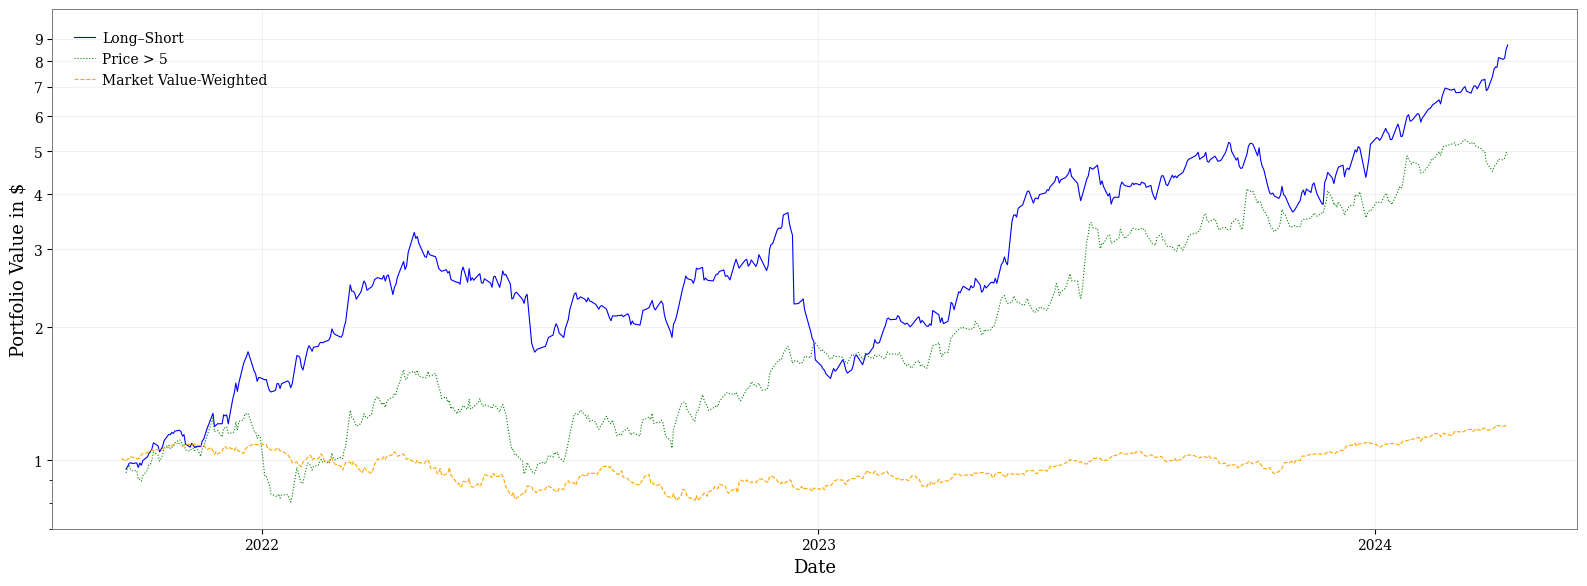

In [30]:
gts.plot_like_paper(
    cumret_long_short,
    cumret_not_small,
    cumret_price5,
    cumret_market
)

## 10. Conclusion

This notebook provided a short tour of the cleaned data and the main analysis in the replication project. It showed how labeled news headlines were divided into intraday and overnight samples, merged with stock price data, transformed into event-based returns, and used to construct portfolio results.

The final performance table and cumulative return figure summarize the central outputs of the replication and provide a transparent overview of the workflow.